Polinom Regresyon Intercept: [99393.54577624]
Polinom Regresyon Katsayıları (Coef): [[ 0.00000000e+00 -2.66306426e+00  5.67196997e-05]]
Basit Doğrusal Reg r2: 0.5518147334399537
Polinom Reg r2: 0.6641120624315482


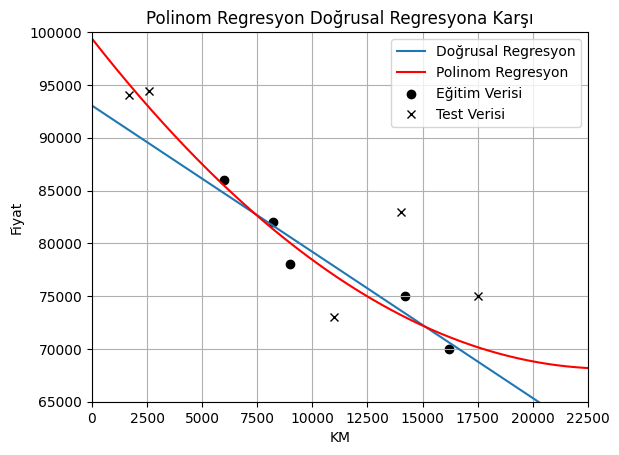

In [ ]:
###########  Ploinom Regresyon ################
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Veri Setlerinin Hazırlanması (Eğitim ve Test)
X_train = [[6000], [8200], [9000], [14200], [16200]]
y_train = [[86000], [82000], [78000], [75000], [70000]]

X_test = [[1700], [2600], [11000], [14000], [17500]]
y_test = [[94000], [94400], [73000], [83000], [75000]]

# 2. Basit Doğrusal Regresyon Modelinin Oluşturulması
model = LinearRegression()
model.fit(X_train, y_train)

# Görselleştirme için tahmin aralığı (0 - 25.000 KM)
xx = np.linspace(0, 25000, 150000)
yy = model.predict(xx.reshape(xx.shape[0], 1))

# 3. Polinom Regresyon (Derece = 2)
polinom_derecesi = PolynomialFeatures(degree=2)
X_train_polinom = polinom_derecesi.fit_transform(X_train)
X_test_polinom = polinom_derecesi.transform(X_test)

polinom_regresyon = LinearRegression()
polinom_regresyon.fit(X_train_polinom, y_train)

# Polinom tahmini için xx verisinin dönüştürülmesi
xx_polinom = polinom_derecesi.transform(xx.reshape(xx.shape[0], 1))
yy_polinom = polinom_regresyon.predict(xx_polinom)

# 4. Model Parametreleri
print("Polinom Regresyon Intercept:", polinom_regresyon.intercept_)
print("Polinom Regresyon Katsayıları (Coef):", polinom_regresyon.coef_)

# 5. Başarı Skorlarının Karşılaştırılması (R2 Skoru)
print('Basit Doğrusal Reg r2:', model.score(X_test, y_test))
print('Polinom Reg r2:', polinom_regresyon.score(X_test_polinom, y_test))

# 6. Grafik 3: Doğrusal vs Polinom Regresyon Karşılaştırması
plt.figure()
plt.title("Polinom Regresyon Doğrusal Regresyona Karşı")
plt.xlabel('KM')
plt.ylabel("Fiyat")

# Modellerin Çizimi
plt.plot(xx, yy, label='Doğrusal Regresyon') # Basit doğrusal
plt.plot(xx, yy_polinom, c='r', linestyle='-', label='Polinom Regresyon') # Polinom

# Veri Noktaları
plt.scatter(X_train, y_train, color="black", label='Eğitim Verisi')
plt.plot(X_test, y_test, 'x', color='black', label='Test Verisi')

plt.axis([0, 22500, 65000, 100000])
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# 7. Farklı Derecelerle Deneme (Örn: Derece = 3)
polinom_derecesi_3 = PolynomialFeatures(degree=3)
X_train_polinom_3 = polinom_derecesi_3.fit_transform(X_train)
polinom_regresyon_3 = LinearRegression()
polinom_regresyon_3.fit(X_train_polinom_3, y_train)

LinearRegression()

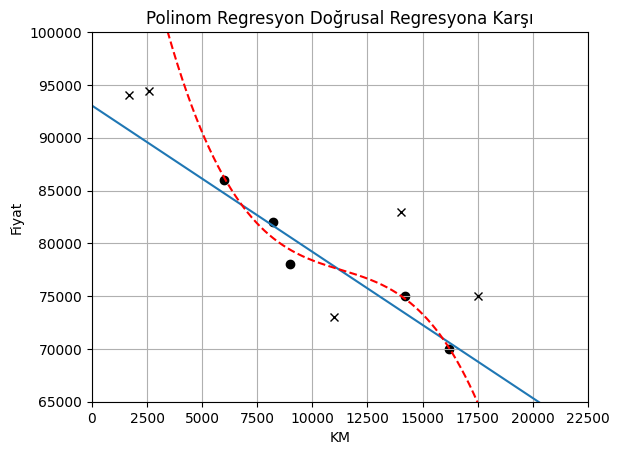

In [ ]:
# 8. Grafik 4: 3. Derece Polinom Tahmin Eğrisi
plt.figure()
plt.title("Polinom Regresyon Doğrusal Regresyona Karşı")
plt.xlabel('KM')
plt.ylabel("Fiyat")

# Doğrusal regresyon çizgisi
plt.plot(xx, yy)

# 3. Derece Polinom regresyon tahmin eğrisi (Kırmızı kesikli çizgi)
plt.plot(xx, polinom_regresyon_3.predict(polinom_derecesi_3.transform(xx.reshape(xx.shape[0], 1))), c='r', linestyle='--')

# Grafik sınırları ve ızgara
plt.axis([0, 22500, 65000, 100000])
plt.grid(True)

# Eğitim verileri (Nokta) ve Test verileri (X işareti)
plt.scatter(X_train, y_train, color="black")
plt.plot(X_test, y_test, 'x', color='black')

plt.show()

In [ ]:
import pandas as pd

# Listeleri bir sözlük yapısında birleştirelim
veri_sozlugu = {
    'KM': [item[0] for item in X_train],
    'Fiyat': [item[0] for item in y_train]
}

# DataFrame oluşturma
df = pd.DataFrame(veri_sozlugu)

# Şimdi istediğiniz komutları uygulayabilirsiniz:
print("--- df.head() Sonucu ---")
print(df.head())

print("\n--- df.describe() Sonucu ---")
print(df.describe())

--- df.head() Sonucu ---
      KM  Fiyat
0   6000  86000
1   8200  82000
2   9000  78000
3  14200  75000
4  16200  70000

--- df.describe() Sonucu ---
                 KM         Fiyat
count      5.000000      5.000000
mean   10720.000000  78200.000000
std     4293.250517   6180.614856
min     6000.000000  70000.000000
25%     8200.000000  75000.000000
50%     9000.000000  78000.000000
75%    14200.000000  82000.000000
max    16200.000000  86000.000000


In [ ]:
# 5. Başarı Skorlarının Yazdırılması
r2_dogrusal = model.score(X_test, y_test)
r2_polinom = polinom_regresyon.score(X_test_polinom, y_test)

print(f"Basit Doğrusal Regresyon R2 Skoru: {r2_dogrusal:.2f}")
print(f"Polinom Regresyon (Derece 2) R2 Skoru: {r2_polinom:.2f}")

# 2. Yeni Bir Veri İçin Fiyat Tahmini Yapma
# Örnek: 15.000 KM'de olan bir aracın fiyatını merak ediyoruz.
yeni_km = np.array([[15000]])

# Önemli: Tahmin yapmadan önce veriyi 2. derece polinom formatına dönüştürmeliyiz
yeni_km_polinom = polinom_derecesi.transform(yeni_km)
tahmin_edilen_fiyat = polinom_regresyon.predict(yeni_km_polinom)

print("-" * 30)
print(f"Tahmin Senaryosu: {yeni_km[0][0]} KM'deki bir araç")
print(f"Tahmini Fiyat: {tahmin_edilen_fiyat[0][0]:.2f} TL")

Basit Doğrusal Regresyon R2 Skoru: 0.55
Polinom Regresyon (Derece 2) R2 Skoru: 0.66
------------------------------
Tahmin Senaryosu: 15000 KM'deki bir araç
Tahmini Fiyat: 72209.51 TL


In [ ]:
# Example: Creating dummy data
X_train = [[6000], [8200], [9000], [14200], [16200]]
y_train = [[86000], [82000], [78000], [75000], [70000]]

# Now your existing code will work:
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
std_X_train = np.std(X_train_np)
mean_X_train = np.mean(X_train_np)
std_y_train = np.std(y_train_np)
mean_y_train = np.mean(y_train_np)
print(f"Standart Sapma (X_train): {std_X_train}")
print(f"Ortalama (X_train): {mean_X_train}")
print(f"Standart Sapma (y_train): {std_y_train}")
print(f"Ortalama (y_train): {mean_y_train}")

Standart Sapma (X_train): 3840.0
Ortalama (X_train): 10720.0
Standart Sapma (y_train): 5528.1099844341015
Ortalama (y_train): 78200.0
